# Prediction Oil Temperature with ETTm1 dataset

Demo notebook — imports preprocessing, training, evaluation from modular `.py` files.

## Import Libraries & Modules

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("."))

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# ── Project modules ──
import config as cfg
from src.data.preprocessing import (
    load_and_split, fit_stl, apply_stl_features,
    add_time_features, compute_clip_bounds, winsorize,
    fit_scaler, scale, build_pipeline, inverse_transform_target,
)
from src.data.dataset import TimeSeriesDataset4Seq, ETTDatasetInformer
from src.models.seq2seq import Seq2SeqLSTM
from src.models.informer import Informer
from src.utils.metrics import metric
from src.utils.tools import EarlyStopping, plot_history

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## Read Dataset

In [2]:
df = pd.read_csv(cfg.DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")
print(f"Shape: {df.shape}")
df.head()

Shape: (69680, 7)


,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
date,,,,,,,
2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
2016-07-01 00:15:00,5.760,2.076,1.492,0.426,4.264,1.401,30.459999
2016-07-01 00:30:00,5.760,1.942,1.492,0.391,4.234,1.310,30.038000
2016-07-01 00:45:00,5.760,1.942,1.492,0.426,4.234,1.310,27.013000
2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001


## Dataset Information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 69680 entries, 2016-07-01 00:00:00 to 2018-06-26 19:45:00
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   HUFL    69680 non-null  float64
 1   HULL    69680 non-null  float64
 2   MUFL    69680 non-null  float64
 3   MULL    69680 non-null  float64
 4   LUFL    69680 non-null  float64
 5   LULL    69680 non-null  float64
 6   OT      69680 non-null  float64
dtypes: float64(7)
memory usage: 4.3 MB


In [4]:
df.describe()

,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
count,69680.000000,69680.000000,69680.000000,69680.000000,69680.000000,69680.000000,69680.000000
mean,7.413993,2.261418,4.322226,0.896509,3.082888,0.857907,13.320642
std,7.082928,2.041293,6.829189,1.807239,1.174063,0.600440,8.564817
min,-23.242001,-5.693000,-26.367001,-6.041000,-1.188000,-1.371000,-4.221000
25%,5.827000,0.804000,3.305000,-0.284000,2.315000,0.670000,6.964000
50%,8.841000,2.210000,6.005000,0.959000,2.833000,0.975000,11.396000
75%,11.788000,3.684000,8.635000,2.203000,3.655000,1.218000,18.079000
max,24.180000,10.315000,18.087000,7.853000,8.498000,3.046000,46.007000


## Train / Val / Test Split Info

In [5]:
n = len(df)
train_size = int(n * cfg.TRAIN_RATIO)
val_size   = int(n * cfg.VAL_RATIO)
test_size  = n - train_size - val_size
print(f"Train: {train_size} | Val: {val_size} | Test: {test_size}")

Train: 41808 | Val: 13936 | Test: 13936


## Exploratory Data Analysis

### 5.1 Histogram of Target Variable (OT)

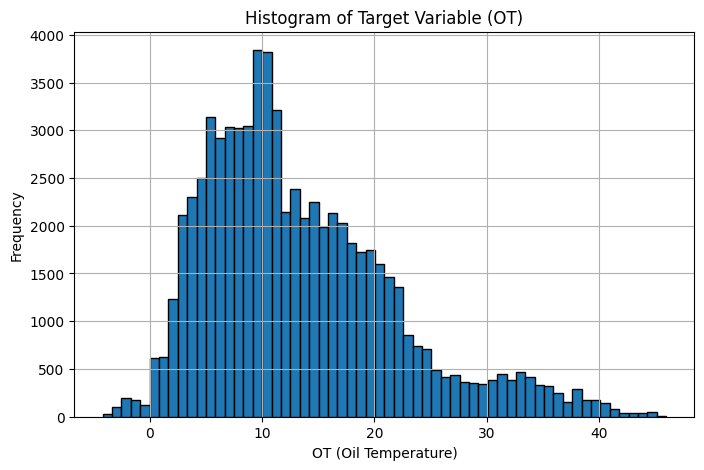

In [6]:
plt.figure(figsize=(8, 5))
plt.hist(df["OT"], bins=60, edgecolor="black")
plt.title("Histogram of Target Variable (OT)")
plt.xlabel("OT (Oil Temperature)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

### 5.2 Correlation Heatmap

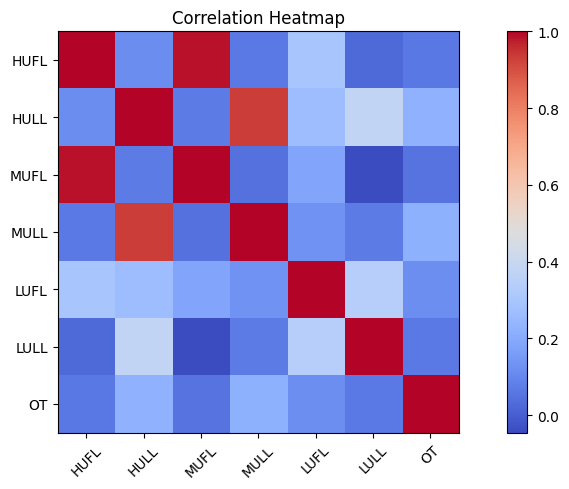

In [7]:
correlation = df.corr()
plt.figure(figsize=(10, 5))
plt.imshow(correlation, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## Preprocessing Pipeline

All steps (STL, time features, winsorize, scale) imported from `src.data.preprocessing`.

In [8]:
# Full pipeline (fit on train only — no data leakage)
train_df, val_df, test_df = load_and_split(cfg.DATA_PATH, cfg.TRAIN_RATIO, cfg.VAL_RATIO)

# Drop highly-correlated columns
if hasattr(cfg, "DROP_COLS") and cfg.DROP_COLS:
    train_df = train_df.drop(columns=cfg.DROP_COLS, errors="ignore")
    val_df   = val_df.drop(columns=cfg.DROP_COLS, errors="ignore")
    test_df  = test_df.drop(columns=cfg.DROP_COLS, errors="ignore")

# Drop highly-correlated columns
if hasattr(cfg, "DROP_COLS") and cfg.DROP_COLS:
    train_df = train_df.drop(columns=cfg.DROP_COLS, errors="ignore")
    val_df   = val_df.drop(columns=cfg.DROP_COLS, errors="ignore")
    test_df  = test_df.drop(columns=cfg.DROP_COLS, errors="ignore")

# STL decomposition
_, seasonal_pattern = fit_stl(train_df, cfg.TARGET_COL, cfg.STL_PERIOD)
train_df = apply_stl_features(train_df, seasonal_pattern, cfg.TARGET_COL, cfg.STL_PERIOD)
val_df   = apply_stl_features(val_df,   seasonal_pattern, cfg.TARGET_COL, cfg.STL_PERIOD)
test_df  = apply_stl_features(test_df,  seasonal_pattern, cfg.TARGET_COL, cfg.STL_PERIOD)

# Time features
train_df = add_time_features(train_df)
val_df   = add_time_features(val_df)
test_df  = add_time_features(test_df)

# Winsorize
bounds   = compute_clip_bounds(train_df)
train_df = winsorize(train_df, bounds)
val_df   = winsorize(val_df,   bounds)
test_df  = winsorize(test_df,  bounds)

# Scale
scaler       = fit_scaler(train_df)
train_scaled = scale(train_df, scaler)
val_scaled   = scale(val_df,   scaler)
test_scaled  = scale(test_df,  scaler)

col_names  = list(train_df.columns)
target_idx = col_names.index(cfg.TARGET_COL)

print(f"Columns ({len(col_names)}): {col_names}")
print(f"Target index: {target_idx}")
print(f"Train: {train_scaled.shape} | Val: {val_scaled.shape} | Test: {test_scaled.shape}")

Columns (10): ['HUFL', 'HULL', 'LUFL', 'LULL', 'OT', 'trend', 'seasonal', 'residual', 'time_sin', 'time_cos']
Target index: 4
Train: (41808, 10) | Val: (13936, 10) | Test: (13936, 10)


In [9]:
train_df.head()

,HUFL,HULL,LUFL,LULL,OT,trend,seasonal,residual,time_sin,time_cos
date,,,,,,,,,,
2016-07-01 00:00:00,5.827,2.009,4.203,1.340,30.531000,30.5310,-0.520875,0.520875,0.000000,1.000000
2016-07-01 00:15:00,5.760,2.076,4.264,1.401,30.459999,30.4955,-0.512512,0.477012,0.065403,0.997859
2016-07-01 00:30:00,5.760,1.942,4.234,1.310,30.038000,30.3430,-0.627023,0.322023,0.130526,0.991445
2016-07-01 00:45:00,5.760,1.942,4.234,1.310,27.013000,29.5105,-0.648687,-1.848813,0.195090,0.980785
2016-07-01 01:00:00,5.693,2.076,4.142,1.371,27.787001,29.1658,-0.653741,-0.725059,0.258819,0.965926


## Distribution Before & After Scaling

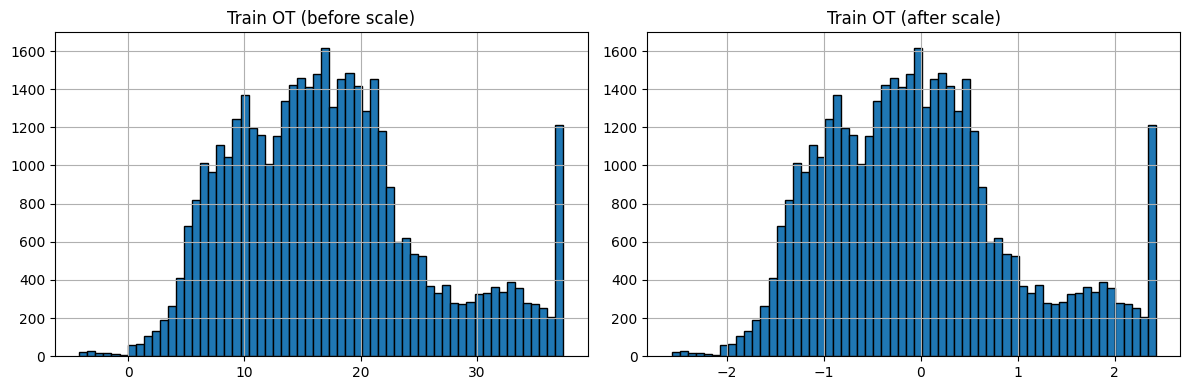

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_df["OT"], bins=60, edgecolor="black")
axes[0].set_title("Train OT (before scale)")
axes[0].grid(True)

axes[1].hist(train_scaled[:, target_idx], bins=60, edgecolor="black")
axes[1].set_title("Train OT (after scale)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Build Datasets & DataLoaders

In [11]:
# ── Seq2Seq datasets ──
train_ds_seq = TimeSeriesDataset4Seq(train_scaled, cfg.SEQ_LEN, cfg.PRED_LEN)
val_ds_seq   = TimeSeriesDataset4Seq(val_scaled,   cfg.SEQ_LEN, cfg.PRED_LEN)
test_ds_seq  = TimeSeriesDataset4Seq(test_scaled,  cfg.SEQ_LEN, cfg.PRED_LEN)

train_loader_seq = DataLoader(train_ds_seq, batch_size=cfg.S2S_BATCH_SIZE, shuffle=True)
val_loader_seq   = DataLoader(val_ds_seq,   batch_size=cfg.S2S_BATCH_SIZE, shuffle=False)
test_loader_seq  = DataLoader(test_ds_seq,  batch_size=cfg.S2S_BATCH_SIZE, shuffle=False)

# ── Informer datasets ──
train_ds_inf = ETTDatasetInformer(train_scaled, train_df.index, cfg.SEQ_LEN, cfg.LABEL_LEN, cfg.PRED_LEN)
val_ds_inf   = ETTDatasetInformer(val_scaled,   val_df.index,   cfg.SEQ_LEN, cfg.LABEL_LEN, cfg.PRED_LEN)
test_ds_inf  = ETTDatasetInformer(test_scaled,  test_df.index,  cfg.SEQ_LEN, cfg.LABEL_LEN, cfg.PRED_LEN)

train_loader_inf = DataLoader(train_ds_inf, batch_size=cfg.INF_BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader_inf   = DataLoader(val_ds_inf,   batch_size=cfg.INF_BATCH_SIZE, shuffle=False, drop_last=True)
test_loader_inf  = DataLoader(test_ds_inf,  batch_size=cfg.INF_BATCH_SIZE, shuffle=False, drop_last=True)

print(f"Seq2Seq  — Train: {len(train_ds_seq)} | Val: {len(val_ds_seq)} | Test: {len(test_ds_seq)}")
print(f"Informer — Train: {len(train_ds_inf)} | Val: {len(val_ds_inf)} | Test: {len(test_ds_inf)}")

Seq2Seq  — Train: 41689 | Val: 13817 | Test: 13817
Informer — Train: 41689 | Val: 13817 | Test: 13817


---
## Seq2SeqLSTM Model

Model architecture imported from `src.models.seq2seq`.

In [12]:
seq2seq_model = Seq2SeqLSTM(
    input_dim   = train_scaled.shape[1],
    hidden_size = cfg.S2S_HIDDEN_SIZE,
    num_layers  = cfg.S2S_NUM_LAYERS,
    dropout     = cfg.S2S_DROPOUT,
    dec_in_dim  = cfg.DEC_IN_DIM,
    pred_len    = cfg.PRED_LEN,
    target_idx  = target_idx,
).to(device)

print(seq2seq_model)
total_params = sum(p.numel() for p in seq2seq_model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")

Seq2SeqLSTM(
  (encoder): Encoder(
    (lstm): LSTM(10, 64, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  )
  (decoder): Decoder(
    (attn): Attention()
    (lstm): LSTM(131, 128, num_layers=2, batch_first=True, dropout=0.5)
    (fc): Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.5, inplace=False)
      (3): Linear(in_features=128, out_features=1, bias=True)
    )
  )
)

Total trainable parameters: 420,609


### 9.1 Train Seq2Seq

Training logic from `train_seq2seq.py`.

In [13]:
from train_seq2seq import train as train_s2s

s2s_optimizer = torch.optim.AdamW(seq2seq_model.parameters(), lr=cfg.S2S_LR, weight_decay=cfg.S2S_WEIGHT_DECAY)
s2s_criterion = nn.MSELoss()
s2s_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(s2s_optimizer, mode="min", patience=3, factor=0.5)

os.makedirs(cfg.CKPT_DIR, exist_ok=True)

s2s_history = train_s2s(
    seq2seq_model, train_loader_seq, val_loader_seq,
    s2s_optimizer, s2s_criterion, s2s_scheduler,
    device, scaler, target_idx,
    cfg.S2S_EPOCHS, cfg.S2S_PATIENCE, cfg.S2S_CKPT,
)

Epoch 001 | Train 4.9821 | Val 4.8244 | LR 0.000500
  Val loss improved to 4.8244  -> checkpoint saved.
Epoch 002 | Train 2.2270 | Val 7.0094 | LR 0.000500
  EarlyStopping counter: 1/5
Epoch 003 | Train 2.1190 | Val 1.5207 | LR 0.000500
  Val loss improved to 1.5207  -> checkpoint saved.
Epoch 004 | Train 2.0619 | Val 2.3403 | LR 0.000500
  EarlyStopping counter: 1/5
Epoch 005 | Train 2.0039 | Val 4.7915 | LR 0.000500
  EarlyStopping counter: 2/5
Epoch 006 | Train 1.9919 | Val 4.4270 | LR 0.000500
  EarlyStopping counter: 3/5
Epoch 007 | Train 1.9914 | Val 3.3101 | LR 0.000500
  EarlyStopping counter: 4/5
Epoch 008 | Train 1.9259 | Val 4.1921 | LR 0.000250
  EarlyStopping counter: 5/5
Early stopping triggered.


### 9.2 Seq2Seq Training Loss

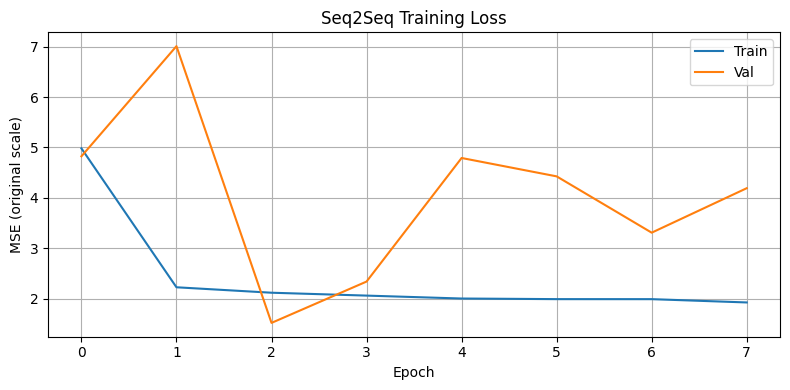

In [14]:
plot_history(s2s_history, title="Seq2Seq Training Loss")

### 9.3 Predict — Seq2Seq

In [15]:
def predict_seq2seq(model, test_loader, scaler, target_idx, device):
    """Load best checkpoint and run prediction on test set."""
    model.load_state_dict(torch.load(cfg.S2S_CKPT, map_location=device))
    model.eval()

    preds_list, trues_list = [], []
    with torch.no_grad():
        for X_batch, Y_batch in test_loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)
            y_target = Y_batch[:, :, target_idx]

            # Future covariates: only sin/cos (last 2 columns)
            future_feat = Y_batch[:, :, -2:]

            out = model(X_batch, y=None, future_features=future_feat, teacher_forcing_ratio=0.0)
            preds_list.append(inverse_transform_target(out.cpu().numpy(), scaler, target_idx))
            trues_list.append(inverse_transform_target(y_target.cpu().numpy(), scaler, target_idx))

    preds = np.concatenate(preds_list, axis=0)
    trues = np.concatenate(trues_list, axis=0)
    return preds, trues

s2s_preds, s2s_trues = predict_seq2seq(seq2seq_model, test_loader_seq, scaler, target_idx, device)
s2s_metrics = metric(s2s_preds, s2s_trues)
print("Seq2Seq Test Metrics:")
for k, v in s2s_metrics.items():
    print(f"  {k}: {v:.4f}")

Seq2Seq Test Metrics:
  MAE: 0.7911
  MSE: 1.2442
  RMSE: 1.1155
  MAPE: 7358835.8274


### 9.4 Seq2Seq — Prediction Visualization

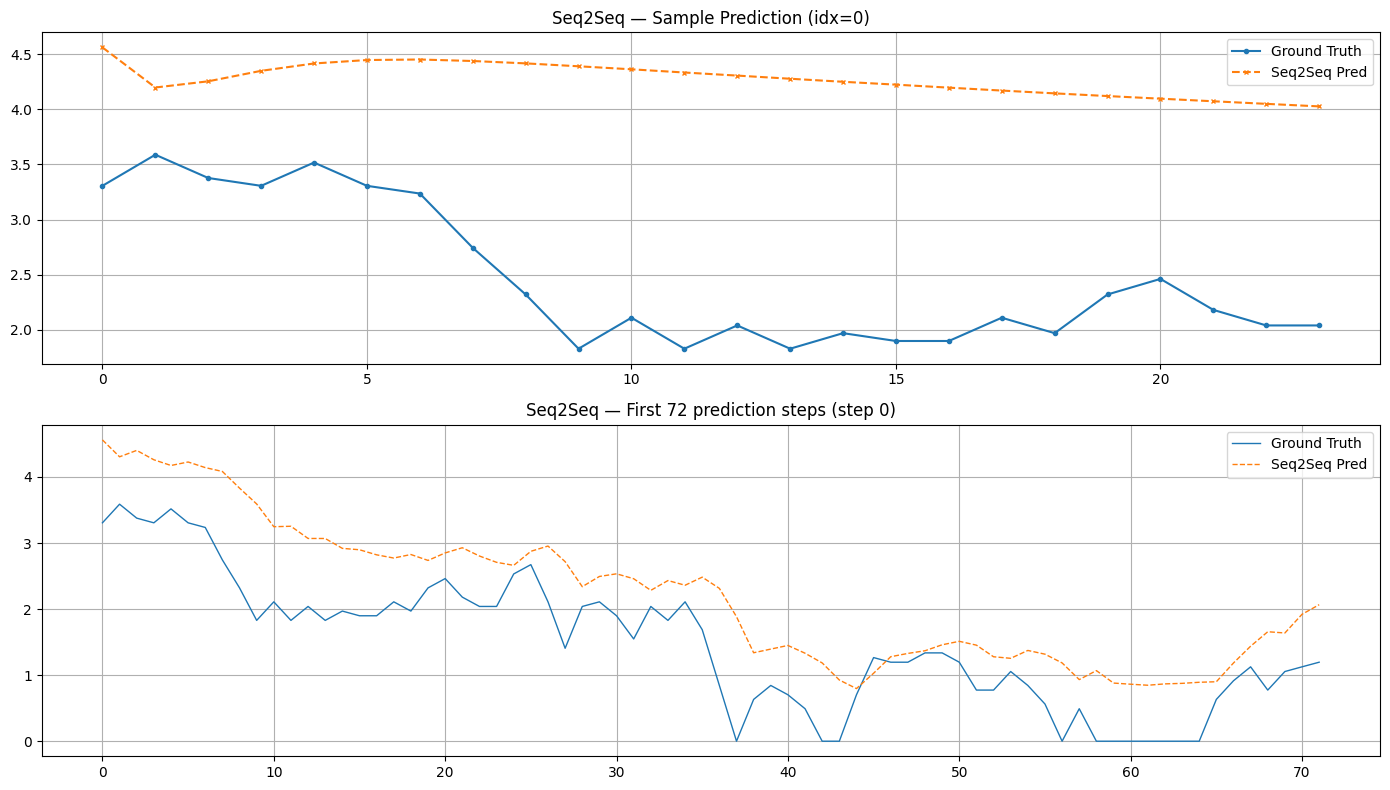

In [16]:
n_show = cfg.PRED_LEN * 3
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot first sample
axes[0].plot(s2s_trues[0], label="Ground Truth", marker="o", markersize=3)
axes[0].plot(s2s_preds[0], label="Seq2Seq Pred", marker="x", markersize=3, linestyle="--")
axes[0].set_title("Seq2Seq — Sample Prediction (idx=0)")
axes[0].legend()
axes[0].grid(True)

# Plot continuous first n_show steps
axes[1].plot(s2s_trues[:n_show, 0], label="Ground Truth", linewidth=1)
axes[1].plot(s2s_preds[:n_show, 0], label="Seq2Seq Pred", linewidth=1, linestyle="--")
axes[1].set_title(f"Seq2Seq — First {n_show} prediction steps (step 0)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

---
## Informer Model

Model architecture imported from `src.models.informer`.

In [17]:
informer_model = Informer(
    enc_in    = cfg.INF_ENC_IN,
    dec_in    = cfg.INF_DEC_IN,
    c_out     = cfg.INF_C_OUT,
    seq_len   = cfg.SEQ_LEN,
    label_len = cfg.LABEL_LEN,
    out_len   = cfg.PRED_LEN,
    factor    = cfg.INF_FACTOR,
    d_model   = cfg.INF_D_MODEL,
    n_heads   = cfg.INF_N_HEADS,
    e_layers  = cfg.INF_E_LAYERS,
    d_layers  = cfg.INF_D_LAYERS,
    d_ff      = cfg.INF_D_FF,
    dropout   = cfg.INF_DROPOUT,
    attn      = cfg.INF_ATTN,
    embed     = cfg.INF_EMBED,
    freq      = cfg.INF_FREQ,
    activation= cfg.INF_ACTIVATION,
    output_attention=cfg.INF_OUTPUT_ATTENTION,
    distil    = cfg.INF_DISTIL,
    mix       = cfg.INF_MIX,
    device    = device,
).float().to(device)

print(informer_model)
total_params = sum(p.numel() for p in informer_model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")

Informer(
  (enc_embedding): DataEmbedding(
    (value_embedding): TokenEmbedding(
      (tokenConv): Conv1d(10, 64, kernel_size=(3,), stride=(1,), padding=(1,), padding_mode=circular)
    )
    (position_embedding): PositionalEmbedding()
    (temporal_embedding): TimeFeatureEmbedding(
      (embed): Linear(in_features=5, out_features=64, bias=True)
    )
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (dec_embedding): DataEmbedding(
    (value_embedding): TokenEmbedding(
      (tokenConv): Conv1d(3, 64, kernel_size=(3,), stride=(1,), padding=(1,), padding_mode=circular)
    )
    (position_embedding): PositionalEmbedding()
    (temporal_embedding): TimeFeatureEmbedding(
      (embed): Linear(in_features=5, out_features=64, bias=True)
    )
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (encoder): Encoder(
    (attn_layers): ModuleList(
      (0): EncoderLayer(
        (attention): AttentionLayer(
          (inner_attention): ProbAttention(
            (dropout): Dropout(p=0.5, 

### 10.1 Train Informer

Training logic from `train_informer.py`.

In [18]:
from train_informer import train as train_inf, process_batch

inf_optimizer = torch.optim.Adam(informer_model.parameters(), lr=cfg.INF_LR)
inf_criterion = nn.MSELoss()

inf_history = train_inf(
    informer_model, train_loader_inf, val_loader_inf,
    inf_optimizer, inf_criterion,
    cfg.PRED_LEN, cfg.LABEL_LEN, target_idx, device,
    cfg.INF_EPOCHS, cfg.INF_PATIENCE, cfg.INF_CKPT,
)

Epoch 001 | Train 0.223155 | Val 0.044734 | LR 5.00e-05
  Val loss improved to 0.0447  -> checkpoint saved.
Epoch 002 | Train 0.091097 | Val 0.038038 | LR 5.00e-05
  Val loss improved to 0.0380  -> checkpoint saved.
Epoch 003 | Train 0.078648 | Val 0.039601 | LR 5.00e-05
  EarlyStopping counter: 1/5
Epoch 004 | Train 0.072514 | Val 0.038063 | LR 5.00e-05
  EarlyStopping counter: 2/5
Epoch 005 | Train 0.068670 | Val 0.036376 | LR 5.00e-05
  Val loss improved to 0.0364  -> checkpoint saved.
Epoch 006 | Train 0.065506 | Val 0.036043 | LR 5.00e-05
  Val loss improved to 0.0360  -> checkpoint saved.
Epoch 007 | Train 0.063342 | Val 0.035572 | LR 5.00e-05
  Val loss improved to 0.0356  -> checkpoint saved.
Epoch 008 | Train 0.061537 | Val 0.036338 | LR 5.00e-05
  EarlyStopping counter: 1/5
Epoch 009 | Train 0.059683 | Val 0.036262 | LR 5.00e-05
  EarlyStopping counter: 2/5
Epoch 010 | Train 0.058438 | Val 0.034793 | LR 5.00e-05
  Val loss improved to 0.0348  -> checkpoint saved.
Epoch 011 | 

### 10.2 Informer Training Loss

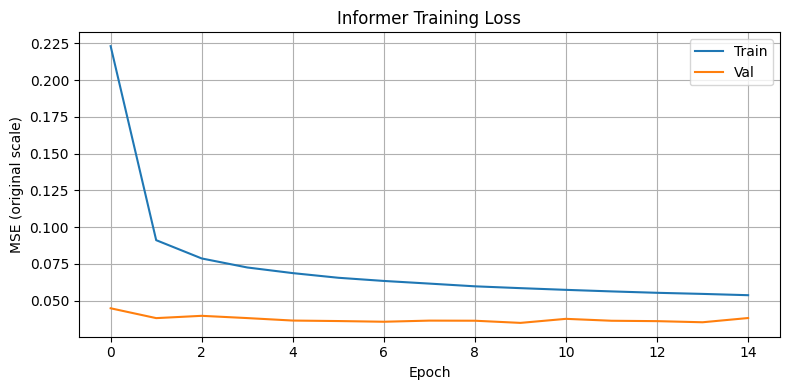

In [19]:
plot_history(inf_history, title="Informer Training Loss")

### 10.3 Predict — Informer

In [20]:
def predict_informer(model, test_loader, scaler, target_idx, device):
    """Load best checkpoint and run prediction on test set."""
    model.load_state_dict(torch.load(cfg.INF_CKPT, map_location=device))
    model.eval()

    preds_list, trues_list = [], []
    with torch.no_grad():
        for enc_x, dec_y, enc_mark, dec_mark in test_loader:
            enc_x    = enc_x.float().to(device)
            dec_y_f  = dec_y.float()
            enc_mark = enc_mark.float().to(device)
            dec_mark = dec_mark.float().to(device)

            # Subset features for Decoder: [OT, time_sin, time_cos]
            batch_y_dec = dec_y_f[:, :, [target_idx, -2, -1]]

            # Decoder input: [label_len history | zero padding]
            pred_pad = torch.zeros([batch_y_dec.shape[0], cfg.PRED_LEN, 3]).float()
            # Inject future sin/cos (indices 1 and 2 in the 3-feature subset)
            pred_pad[:, :, 1:3] = batch_y_dec[:, -cfg.PRED_LEN:, 1:3]
            
            dec_inp = torch.cat([batch_y_dec[:, :cfg.LABEL_LEN, :], pred_pad], dim=1).float().to(device)

            out = model(enc_x, enc_mark, dec_inp, dec_mark)  # (B, pred_len, 1)
            gt  = dec_y_f[:, -cfg.PRED_LEN:, target_idx:target_idx+1]

            preds_list.append(inverse_transform_target(out.squeeze(-1).cpu().numpy(), scaler, target_idx))
            trues_list.append(inverse_transform_target(gt.squeeze(-1).cpu().numpy(), scaler, target_idx))

    preds = np.concatenate(preds_list, axis=0)
    trues = np.concatenate(trues_list, axis=0)
    return preds, trues

inf_preds, inf_trues = predict_informer(informer_model, test_loader_inf, scaler, target_idx, device)
inf_metrics = metric(inf_preds, inf_trues)
print("Informer Test Metrics:")
for k, v in inf_metrics.items():
    print(f"  {k}: {v:.4f}")

Informer Test Metrics:
  MAE: 1.3172
  MSE: 2.7539
  RMSE: 1.6595
  MAPE: 4827910.8123


### 10.4 Informer — Prediction Visualization

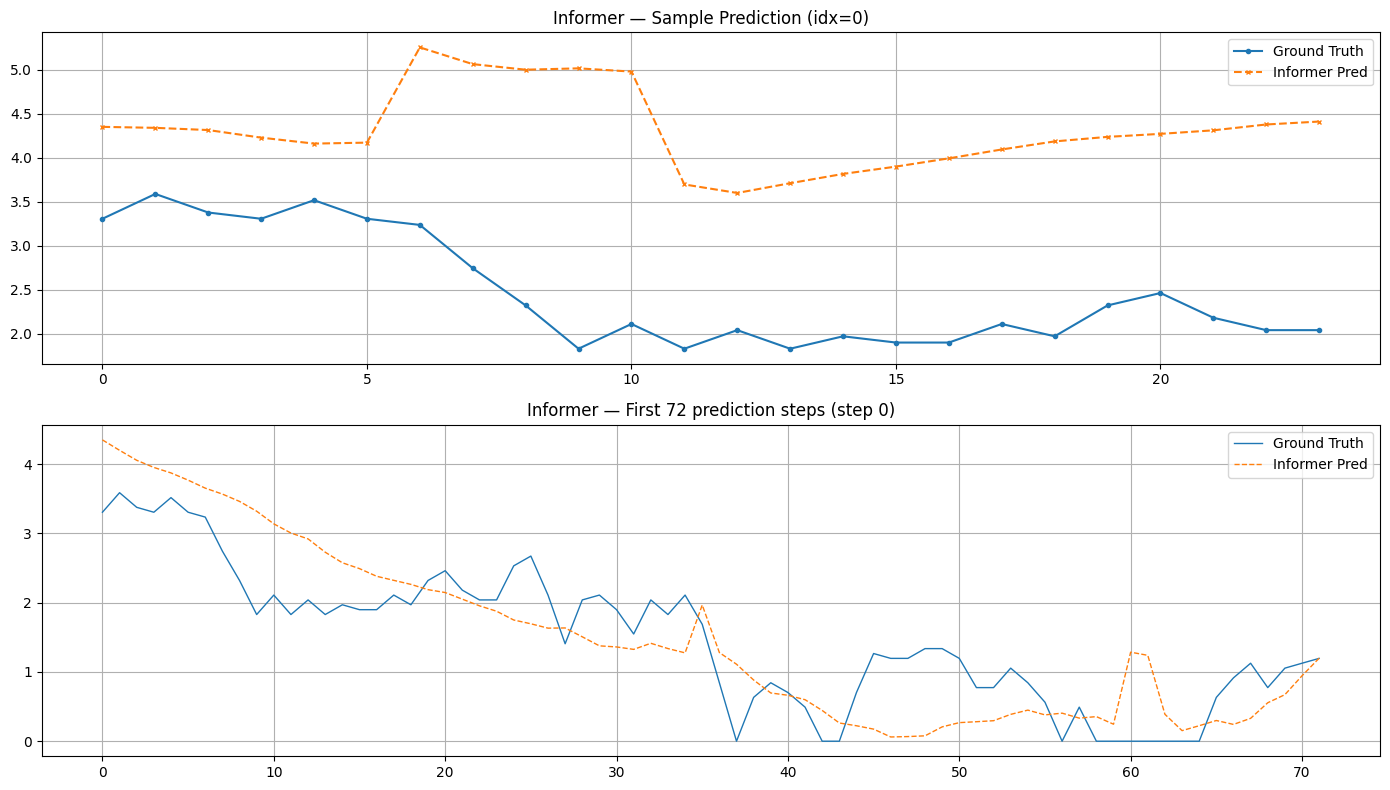

In [21]:
n_show = cfg.PRED_LEN * 3
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(inf_trues[0], label="Ground Truth", marker="o", markersize=3)
axes[0].plot(inf_preds[0], label="Informer Pred", marker="x", markersize=3, linestyle="--")
axes[0].set_title("Informer — Sample Prediction (idx=0)")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(inf_trues[:n_show, 0], label="Ground Truth", linewidth=1)
axes[1].plot(inf_preds[:n_show, 0], label="Informer Pred", linewidth=1, linestyle="--")
axes[1].set_title(f"Informer — First {n_show} prediction steps (step 0)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

---
## Model Comparison

In [22]:
comparison = pd.DataFrame({
    "Seq2Seq": s2s_metrics,
    "Informer": inf_metrics,
}).T

comparison

,MAE,MSE,RMSE,MAPE
Seq2Seq,0.791122,1.244237,1.115454,7.358836e+06
Informer,1.317200,2.753942,1.659501,4.827911e+06


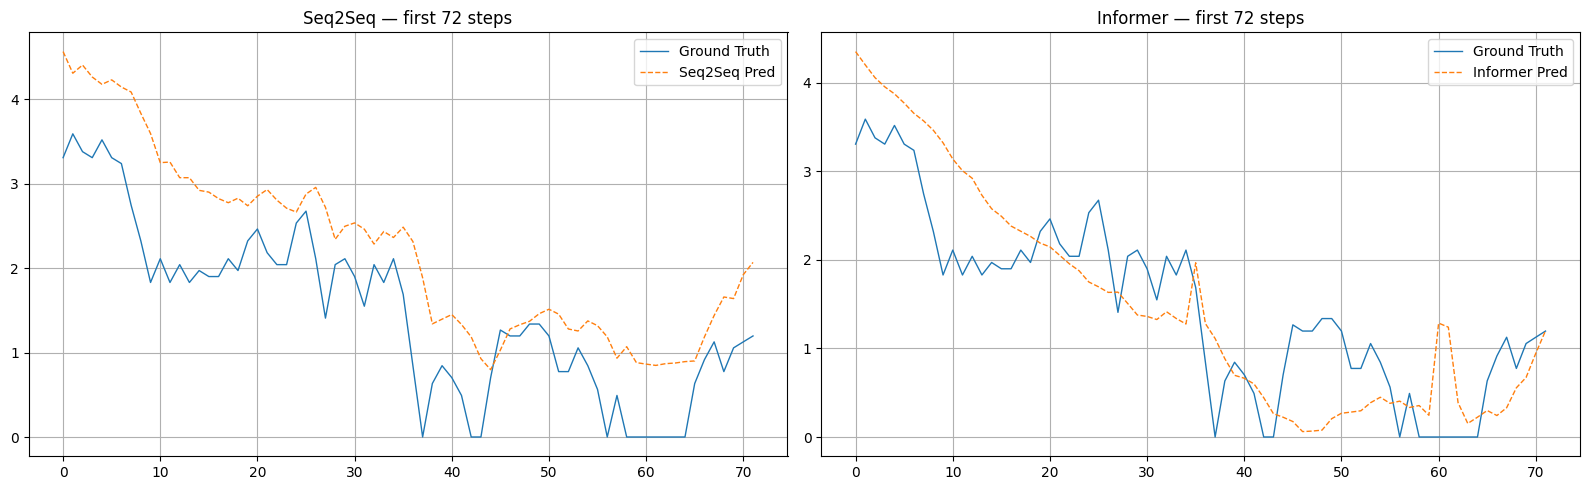

Plot saved!


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
n_show = cfg.PRED_LEN * 3

for ax, name, preds, trues in [
    (axes[0], "Seq2Seq",  s2s_preds, s2s_trues),
    (axes[1], "Informer", inf_preds, inf_trues),
]:
    ax.plot(trues[:n_show, 0], label="Ground Truth", linewidth=1)
    ax.plot(preds[:n_show, 0], label=f"{name} Pred", linewidth=1, linestyle="--")
    ax.set_title(f"{name} — first {n_show} steps")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
os.makedirs(cfg.RESULT_DIR, exist_ok=True)
plt.savefig(os.path.join(cfg.RESULT_DIR, "comparison_plot.png"), dpi=150)
plt.show()
print("Plot saved!")

---
## Predict — Single Sample Demo

Pick a random sample from the test set, predict, and visualize.

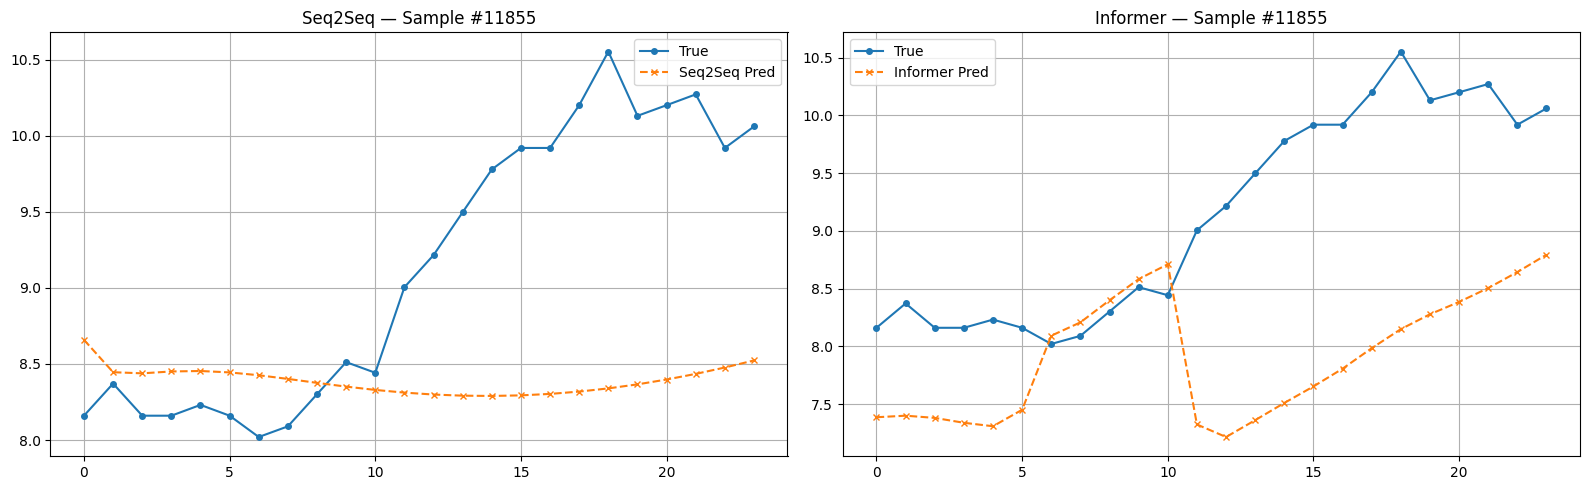


Sample #11855
Seq2Seq  MAE: 0.9473
Informer MAE: 1.2781


In [24]:
import random as _random

def demo_predict_seq2seq(model, test_scaled, scaler, target_idx, device, sample_idx=None):
    """Predict a single sample from test set using Seq2Seq."""
    ds = TimeSeriesDataset4Seq(test_scaled, cfg.SEQ_LEN, cfg.PRED_LEN)
    if sample_idx is None:
        sample_idx = _random.randint(0, len(ds) - 1)

    X, Y = ds[sample_idx]
    X = X.unsqueeze(0).to(device)
    Y = Y.unsqueeze(0).to(device)

    model.load_state_dict(torch.load(cfg.S2S_CKPT, map_location=device))
    model.eval()
    with torch.no_grad():
        # Future features: only sin/cos (last 2 columns)
        future_feat = Y[:, :, -2:]
        pred = model(X, y=None, future_features=future_feat, teacher_forcing_ratio=0.0)

    pred_real = inverse_transform_target(pred.cpu().numpy().flatten(), scaler, target_idx)
    true_real = inverse_transform_target(Y[:, :, target_idx].cpu().numpy().flatten(), scaler, target_idx)
    return pred_real, true_real, sample_idx


def demo_predict_informer(model, test_scaled, test_index, scaler, target_idx, device, sample_idx=None):
    """Predict a single sample from test set using Informer."""
    ds = ETTDatasetInformer(test_scaled, test_index, cfg.SEQ_LEN, cfg.LABEL_LEN, cfg.PRED_LEN)
    if sample_idx is None:
        sample_idx = _random.randint(0, len(ds) - 1)

    enc_x, dec_y, enc_mark, dec_mark = ds[sample_idx]
    enc_x    = enc_x.unsqueeze(0).float().to(device)
    dec_y_f  = dec_y.unsqueeze(0).float()
    enc_mark = enc_mark.unsqueeze(0).float().to(device)
    dec_mark = dec_mark.unsqueeze(0).float().to(device)

    # Subset features for Decoder: [OT, time_sin, time_cos]
    batch_y_dec = dec_y_f[:, :, [target_idx, -2, -1]]
    
    pred_pad = torch.zeros([1, cfg.PRED_LEN, 3]).float()
    # Inject future sin/cos (indices 1 and 2 in the 3-feature subset)
    pred_pad[:, :, 1:3] = batch_y_dec[:, -cfg.PRED_LEN:, 1:3]
    
    dec_inp = torch.cat([batch_y_dec[:, :cfg.LABEL_LEN, :], pred_pad], dim=1).float().to(device)

    model.load_state_dict(torch.load(cfg.INF_CKPT, map_location=device))
    model.eval()
    with torch.no_grad():
        out = model(enc_x, enc_mark, dec_inp, dec_mark)

    pred_real = inverse_transform_target(out.squeeze(-1).cpu().numpy().flatten(), scaler, target_idx)
    gt = dec_y_f[:, -cfg.PRED_LEN:, target_idx]
    true_real = inverse_transform_target(gt.cpu().numpy().flatten(), scaler, target_idx)
    return pred_real, true_real, sample_idx

# ── Run demo ──
idx = _random.randint(0, len(test_ds_seq) - 1)
s2s_p, s2s_t, _ = demo_predict_seq2seq(seq2seq_model, test_scaled, scaler, target_idx, device, idx)
inf_p, inf_t, _ = demo_predict_informer(informer_model, test_scaled, test_df.index, scaler, target_idx, device, idx)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(s2s_t, "o-", label="True", markersize=4)
axes[0].plot(s2s_p, "x--", label="Seq2Seq Pred", markersize=4)
axes[0].set_title(f"Seq2Seq — Sample #{idx}")
axes[0].legend(); axes[0].grid(True)

axes[1].plot(inf_t, "o-", label="True", markersize=4)
axes[1].plot(inf_p, "x--", label="Informer Pred", markersize=4)
axes[1].set_title(f"Informer — Sample #{idx}")
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"\nSample #{idx}")
print(f"Seq2Seq  MAE: {np.mean(np.abs(s2s_p - s2s_t)):.4f}")
print(f"Informer MAE: {np.mean(np.abs(inf_p - inf_t)):.4f}")

## Model Parameters Summary

In [25]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Seq2Seq  trainable params: {count_parameters(seq2seq_model):,}")
print(f"Informer trainable params: {count_parameters(informer_model):,}")

Seq2Seq  trainable params: 420,609
Informer trainable params: 87,425


In [26]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from src.data.preprocessing import load_and_split, fit_stl, apply_stl_features, add_time_features, winsorize, compute_clip_bounds

# 1. Lấy lại các thông số tiền xử lý từ tập train (seasonal pattern, bounds)
train_df_raw, _, _ = load_and_split(cfg.DATA_PATH, cfg.TRAIN_RATIO, cfg.VAL_RATIO)
_, seasonal_pattern = fit_stl(train_df_raw, cfg.TARGET_COL, cfg.STL_PERIOD)
bounds = compute_clip_bounds(train_df_raw)

# 2. Load custom test data (test_data.xlsx có 96 dòng)
test_custom = pd.read_excel('data/test_data.xlsx')
test_custom['date'] = pd.to_datetime(test_custom['date'])
test_custom.set_index('date', inplace=True)

# 3. Áp dụng chuẩn hóa theo đúng format của train
test_custom = apply_stl_features(test_custom, seasonal_pattern, cfg.TARGET_COL, cfg.STL_PERIOD)
test_custom = add_time_features(test_custom)
test_custom = winsorize(test_custom, bounds)
test_custom_scaled = scaler.transform(test_custom.values)

# 4. Chuẩn bị tensor (1 batch, seq_len=96, features=12)
X_custom = torch.tensor(test_custom_scaled, dtype=torch.float32).unsqueeze(0).to(device)

# 5. Khởi tạo các biến thời gian tương lai (covariates: seasonal, time_sin, time_cos)
last_date = test_custom.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(minutes=15), periods=cfg.PRED_LEN, freq='15min')
future_df = pd.DataFrame(index=future_dates)
future_df['dummy'] = 0
future_df = add_time_features(future_df)

# Tính seasonal pattern cho 24 bước tới
start_offset = (future_dates[0].hour * 4 + future_dates[0].minute // 15) % cfg.STL_PERIOD
idx = [(start_offset + i) % cfg.STL_PERIOD for i in range(cfg.PRED_LEN)]
future_df['seasonal'] = np.array([seasonal_pattern[i] for i in idx])

# Ép vào ma trận tương lai
Y_custom_dummy = torch.zeros((1, cfg.PRED_LEN, X_custom.shape[-1]), device=device)
Y_custom_dummy[0, :, 8] = torch.tensor(future_df['seasonal'].values, dtype=torch.float32).to(device)
Y_custom_dummy[0, :, 10] = torch.tensor(future_df['time_sin'].values, dtype=torch.float32).to(device)
Y_custom_dummy[0, :, 11] = torch.tensor(future_df['time_cos'].values, dtype=torch.float32).to(device)

# Lắp ghép future_feat như trong evaluate.py
future_feat = X_custom[:, -1, :].unsqueeze(1).repeat(1, cfg.PRED_LEN, 1)
known_idx = [8, 10, 11]
future_feat[:, :, known_idx] = Y_custom_dummy[:, :, known_idx]
future_feat = torch.cat([
    future_feat[:, :, :target_idx],
    future_feat[:, :, target_idx + 1:]
], dim=-1)

# 6. Dự đoán bằng Seq2Seq
seq2seq_model.load_state_dict(torch.load(cfg.S2S_CKPT, map_location=device))
seq2seq_model.eval()
with torch.no_grad():
    out = seq2seq_model(X_custom, y=None, future_features=future_feat, teacher_forcing_ratio=0.0)

pred_custom = inverse_transform_target(out.cpu().numpy().flatten(), scaler, target_idx)

# 7. So sánh với label.xlsx
label_custom = pd.read_excel('data/label.xlsx')
true_custom = label_custom['OT'].values

# Vẽ đồ thị
plt.figure(figsize=(10, 5))
plt.plot(true_custom, marker='o', label='Ground Truth (label.xlsx)', color='blue')
plt.plot(pred_custom, marker='x', linestyle='--', label='Seq2Seq Prediction', color='orange')
plt.title("Seq2Seq Evaluation on Custom test_data.xlsx")
plt.legend()
plt.grid(True)
plt.show()

print(f"Custom Data MAE: {np.mean(np.abs(pred_custom - true_custom)):.4f}")


ValueError: X has 12 features, but StandardScaler is expecting 10 features as input.